https://github.com/Azrocks/Customer-Satisfaction-Prediction/tree/main

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("Customer_support_data.csv")

In [5]:
df.shape
df.columns.tolist()
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13749 entries, 0 to 13748
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                13749 non-null  object 
 1   channel_name             13748 non-null  object 
 2   category                 13748 non-null  object 
 3   Sub-category             13748 non-null  object 
 4   Customer Remarks         4500 non-null   object 
 5   Order_id                 9251 non-null   object 
 6   order_date_time          2281 non-null   object 
 7   Issue_reported at        13748 non-null  object 
 8   issue_responded          13748 non-null  object 
 9   Survey_response_Date     13748 non-null  object 
 10  Customer_City            2257 non-null   object 
 11  Product_category         2279 non-null   object 
 12  Item_price               2281 non-null   float64
 13  connected_handling_time  34 non-null     float64
 14  Agent_name            

In [6]:
df.isnull().sum()

,0
Unique id,0
channel_name,1
category,1
Sub-category,1
Customer Remarks,9249
Order_id,4498
order_date_time,11468
Issue_reported at,1
issue_responded,1
Survey_response_Date,1


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['CSAT Score'].value_counts()

,count
CSAT Score,
5.0,9493
1.0,1931
4.0,1702
3.0,418
2.0,204


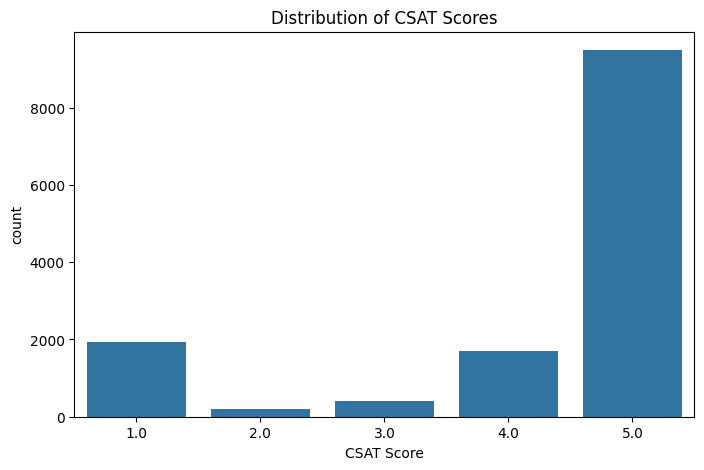

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(x='CSAT Score', data=df)

plt.title("Distribution of CSAT Scores")

plt.show()

# **Observation 1:**

The majority of customers provided a CSAT score of 5, indicating a high level of customer satisfaction. Scores 2 and 3 were the least common.

Insight:

The dataset is highly skewed toward positive customer experiences, suggesting that most support interactions were successful.

In [10]:
df['channel_name'].value_counts()

,count
channel_name,
Inbound,10964
Outcall,2416
Email,368


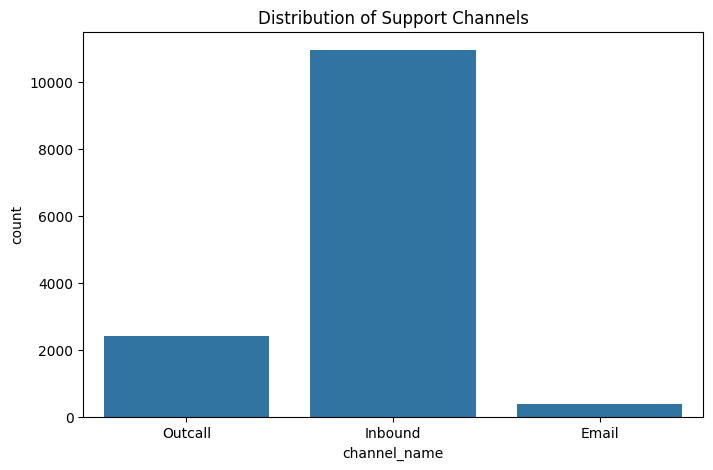

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='channel_name',
    data=df
)

plt.title("Distribution of Support Channels")

plt.show()

# **Observation 2**:

Inbound support accounts for the majority of customer interactions, followed by Outcall and Email channels.

Insight:

Customers primarily rely on inbound support channels when seeking assistance. This suggests that optimizing inbound support operations could significantly improve overall customer experience.

In [12]:
df['category'].value_counts()

,count
category,
Returns,6627
Order Related,3761
Refund Related,764
Product Queries,757
Shopzilla Related,521
Payments related,421
Cancellation,394
Feedback,357
Offers & Cashback,105


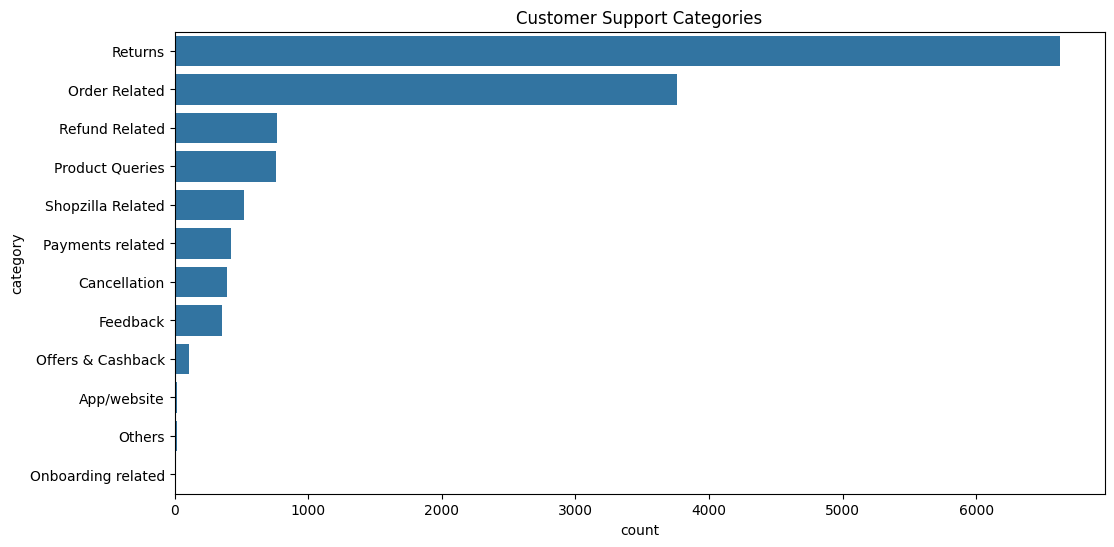

In [13]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='category',
    data=df,
    order=df['category'].value_counts().index
)

plt.title("Customer Support Categories")

plt.show()

#**Observation 3:**

Returns is the most frequent customer support category, followed by Order Related issues.

Insight:

A significant portion of customer support requests are associated with returns and order management. Improving return processes and order tracking systems could reduce support workload and improve customer satisfaction.

In [14]:
df['Agent Shift'].value_counts()

,count
Agent Shift,
Morning,6116
Evening,5317
Afternoon,1196
Split,861
Night,258


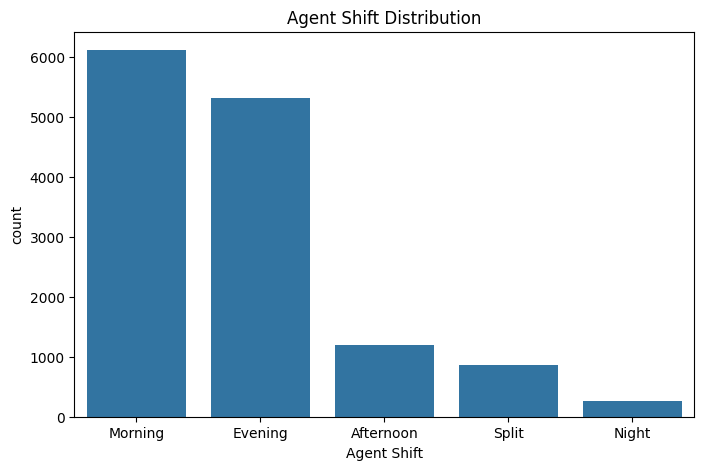

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Agent Shift',
    data=df,
    order=df['Agent Shift'].value_counts().index
)

plt.title("Agent Shift Distribution")

plt.show()

#**Observation 4:**

The Morning shift handles the highest number of customer interactions, followed by the Evening shift.

Insight:

Most customer support demand occurs during daytime hours. Resource allocation should prioritize Morning and Evening shifts to ensure efficient service delivery.

In [16]:
df['Tenure Bucket'].value_counts()

,count
Tenure Bucket,
>90,5802
31-60,2408
0-30,2185
On Job Training,2096
61-90,1257


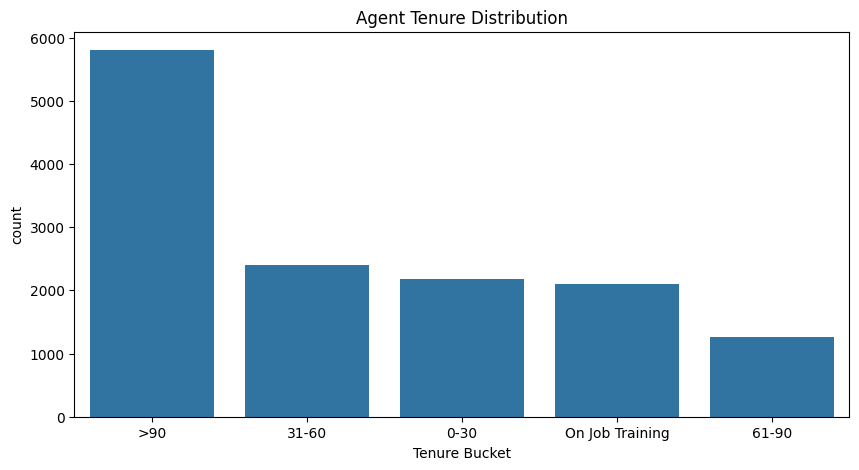

In [17]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='Tenure Bucket',
    data=df,
    order=df['Tenure Bucket'].value_counts().index
)

plt.title("Agent Tenure Distribution")

plt.show()

#**Observation 5:**

Most agents belong to the >90 days tenure bucket, followed by agents undergoing On Job Training.

Insight:

The workforce consists of both experienced and newly trained agents. Further analysis can determine whether agent experience influences customer satisfaction.

In [18]:
df['Issue_reported at'] = pd.to_datetime(
    df['Issue_reported at'],
    dayfirst=True
)

df['issue_responded'] = pd.to_datetime(
    df['issue_responded'],
    dayfirst=True
)

In [19]:
df['Resolution_Time_Hours'] = (
    df['issue_responded']
    -
    df['Issue_reported at']
).dt.total_seconds() / 3600

In [20]:
df[['Issue_reported at',
    'issue_responded',
    'Resolution_Time_Hours']].head()

,Issue_reported at,issue_responded,Resolution_Time_Hours
0,2023-08-01 11:13:00,2023-08-01 11:47:00,0.566667
1,2023-08-01 12:52:00,2023-08-01 12:54:00,0.033333
2,2023-08-01 20:16:00,2023-08-01 20:38:00,0.366667
3,2023-08-01 20:56:00,2023-08-01 21:16:00,0.333333
4,2023-08-01 10:30:00,2023-08-01 10:32:00,0.033333


# ML MODEL
#Random Forest


In [21]:
df = df.drop(
    columns=[
        'Unique id',
        'Order_id',
        'connected_handling_time'
    ]
)

df.columns

Index(['channel_name', 'category', 'Sub-category', 'Customer Remarks',
       'order_date_time', 'Issue_reported at', 'issue_responded',
       'Survey_response_Date', 'Customer_City', 'Product_category',
       'Item_price', 'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket',
       'Agent Shift', 'CSAT Score', 'Resolution_Time_Hours'],
      dtype='object')

In [22]:
df.isnull().sum()

,0
channel_name,1
category,1
Sub-category,1
Customer Remarks,9249
order_date_time,11468
Issue_reported at,1
issue_responded,1
Survey_response_Date,1
Customer_City,11492
Product_category,11470


In [23]:
df = df.drop(
    columns=[
        'Customer Remarks',
        'order_date_time',
        'Customer_City',
        'Product_category'
    ]
)

In [24]:
df.isnull().sum()

,0
channel_name,1
category,1
Sub-category,1
Issue_reported at,1
issue_responded,1
Survey_response_Date,1
Item_price,11468
Agent_name,1
Supervisor,1
Manager,1


In [25]:
df['Item_price'] = df['Item_price'].fillna(
    df['Item_price'].median()
)
df.isnull().sum()

,0
channel_name,1
category,1
Sub-category,1
Issue_reported at,1
issue_responded,1
Survey_response_Date,1
Item_price,0
Agent_name,1
Supervisor,1
Manager,1


In [26]:
df['Report_Hour'] = df['Issue_reported at'].dt.hour

df['Report_Day'] = df['Issue_reported at'].dt.day

df['Report_Month'] = df['Issue_reported at'].dt.month

In [27]:
df = df.drop(
    columns=[
        'Issue_reported at',
        'issue_responded',
        'Survey_response_Date'
    ]
)

In [28]:
df.columns

Index(['channel_name', 'category', 'Sub-category', 'Item_price', 'Agent_name',
       'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score',
       'Resolution_Time_Hours', 'Report_Hour', 'Report_Day', 'Report_Month'],
      dtype='object')

In [29]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = encoder.fit_transform(df[col])
df.head()

,channel_name,category,Sub-category,Item_price,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,Resolution_Time_Hours,Report_Hour,Report_Day,Report_Month
0,2,8,18,999.0,909,26,1,4,2,5.0,0.566667,11.0,1.0,8.0
1,2,8,31,999.0,1128,9,3,3,2,5.0,0.033333,12.0,1.0,8.0
2,1,5,14,999.0,311,18,5,4,1,5.0,0.366667,20.0,1.0,8.0
3,1,10,37,999.0,870,33,2,3,1,5.0,0.333333,20.0,1.0,8.0
4,1,1,21,999.0,205,4,3,0,2,5.0,0.033333,10.0,1.0,8.0


In [30]:
X = df.drop('CSAT Score', axis=1)

y = df['CSAT Score']

In [53]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(10999, 13)
(2750, 13)
(10999,)
(2750,)


In [38]:
from sklearn.ensemble import RandomForestClassifier

In [45]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [71]:
nan_indices = y_train[y_train.isna()].index
X_train_cleaned = X_train.drop(nan_indices)
y_train_cleaned = y_train.drop(nan_indices)

model.fit(X_train_cleaned, y_train_cleaned)

RandomForestClassifier(random_state=42)

In [55]:
predictions = model.predict(X_test)

In [56]:
from sklearn.metrics import accuracy_score

In [57]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy =", accuracy)

Accuracy = 0.6872727272727273


In [58]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(
    y_test,
    predictions
)

print(cm)

[[  46    0    1    5  337]
 [   0    0    0    0   46]
 [   0    0    0    1   82]
 [   8    0    0    5  320]
 [  44    0    0   16 1839]]


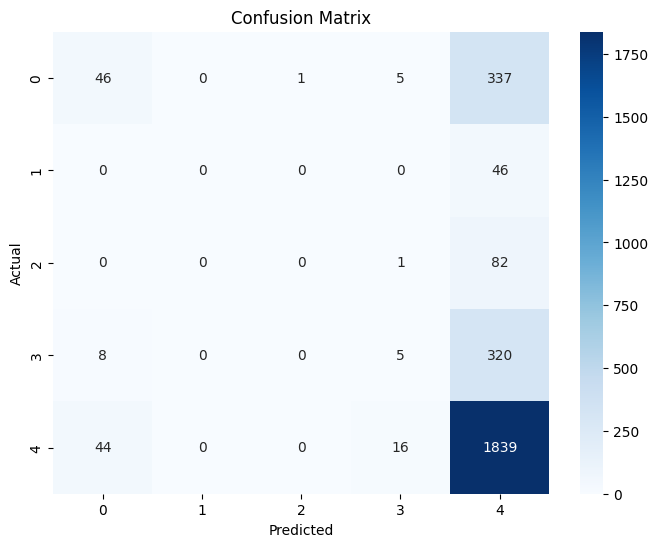

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [60]:
from sklearn.metrics import classification_report
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

         1.0       0.47      0.12      0.19       389
         2.0       0.00      0.00      0.00        46
         3.0       0.00      0.00      0.00        83
         4.0       0.19      0.02      0.03       333
         5.0       0.70      0.97      0.81      1899

    accuracy                           0.69      2750
   macro avg       0.27      0.22      0.21      2750
weighted avg       0.57      0.69      0.59      2750



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [61]:
importance = model.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
4,Agent_name,0.167686
9,Resolution_Time_Hours,0.161937
10,Report_Hour,0.127613
5,Supervisor,0.110057
11,Report_Day,0.087841
2,Sub-category,0.087267
3,Item_price,0.051905
7,Tenure Bucket,0.048783
6,Manager,0.044770
1,category,0.041409


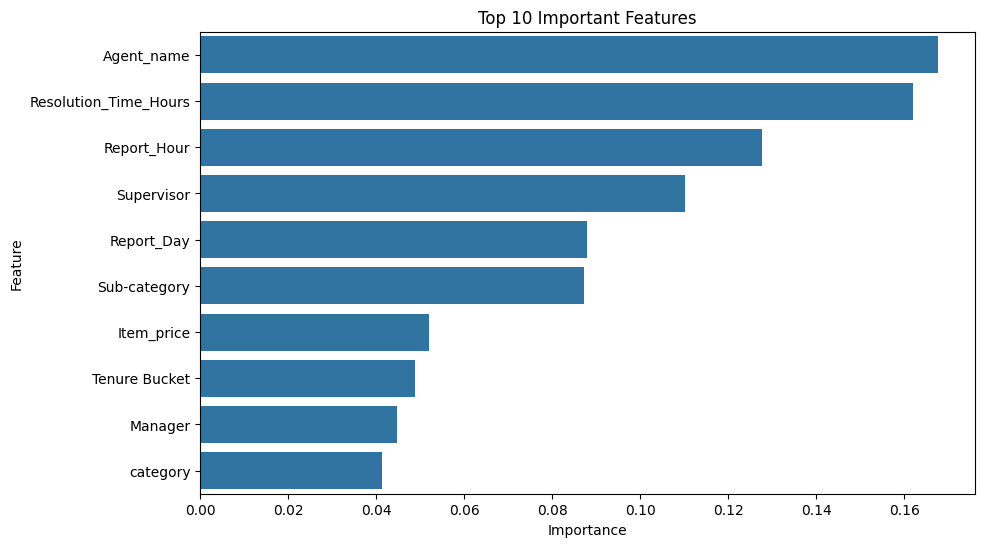

In [63]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

In [64]:
df.head()

,channel_name,category,Sub-category,Item_price,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,Resolution_Time_Hours,Report_Hour,Report_Day,Report_Month
0,2,8,18,999.0,909,26,1,4,2,5.0,0.566667,11.0,1.0,8.0
1,2,8,31,999.0,1128,9,3,3,2,5.0,0.033333,12.0,1.0,8.0
2,1,5,14,999.0,311,18,5,4,1,5.0,0.366667,20.0,1.0,8.0
3,1,10,37,999.0,870,33,2,3,1,5.0,0.333333,20.0,1.0,8.0
4,1,1,21,999.0,205,4,3,0,2,5.0,0.033333,10.0,1.0,8.0


In [65]:
df_ml = df.copy()
df_original = pd.read_csv("Customer_support_data.csv")

In [66]:
df_ml['CSAT Score'] = df_ml['CSAT Score'] - 1

In [67]:
X = df_ml.drop('CSAT Score', axis=1)

y = df_ml['CSAT Score']
print(X.shape)
print(y.shape)

(13749, 13)
(13749,)


In [73]:
from sklearn.model_selection import train_test_split

nan_indices_y = y[y.isna()].index
X_cleaned = X.drop(nan_indices_y)
y_cleaned = y.drop(nan_indices_y)

X_train, X_test, y_train, y_test = train_test_split(
    X_cleaned,
    y_cleaned,
    test_size=0.2,
    random_state=42,
    stratify=y_cleaned
)
print(X_train.shape)
print(X_test.shape)
print(df_original.columns.tolist())

(10998, 13)
(2750, 13)
['Unique id', 'channel_name', 'category', 'Sub-category', 'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at', 'issue_responded', 'Survey_response_Date', 'Customer_City', 'Product_category', 'Item_price', 'connected_handling_time', 'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score']


# XGBoost

In [70]:
!pip install xgboost -q
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
print(sorted(y.unique()))

[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(nan)]


In [72]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective='multi:softprob',
    num_class=5,
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=5, ...)

In [74]:
xgb_pred = xgb_model.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy =", xgb_acc)
print(classification_report(y_test, xgb_pred))
print(sorted(y_train.unique()))
print(sorted(y_test.unique()))

XGBoost Accuracy = 0.6836363636363636
              precision    recall  f1-score   support

         0.0       0.38      0.13      0.20       386
         1.0       0.00      0.00      0.00        41
         2.0       0.00      0.00      0.00        84
         3.0       0.24      0.01      0.03       340
         4.0       0.71      0.96      0.81      1899

    accuracy                           0.68      2750
   macro avg       0.26      0.22      0.21      2750
weighted avg       0.57      0.68      0.59      2750

[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]


#ET Classifier

In [75]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, classification_report
et_model = ExtraTreesClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
et_model.fit(X_train, y_train)

ExtraTreesClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [ ]:
et_pred = et_model.predict(X_test)

In [ ]:
et_acc = accuracy_score(y_test, et_pred)

print("Extra Trees Accuracy =", et_acc)
print(classification_report(y_test, et_pred))

Extra Trees Accuracy = 0.6727971132580608
              precision    recall  f1-score   support

           0       0.32      0.08      0.13      2246
           1       0.00      0.00      0.00       256
           2       0.04      0.00      0.01       512
           3       0.13      0.02      0.04      2244
           4       0.70      0.95      0.81     11924

    accuracy                           0.67     17182
   macro avg       0.24      0.21      0.20     17182
weighted avg       0.55      0.67      0.58     17182



In [77]:
from sklearn.metrics import accuracy_score

et_pred = et_model.predict(X_test)
et_acc = accuracy_score(y_test, et_pred)

comparison = pd.DataFrame({
    'Model': [
        'Random Forest',
        'XGBoost',
        'Extra Trees'
    ],
    'Accuracy': [
        accuracy,
        xgb_acc,
        et_acc
    ]
})

comparison

,Model,Accuracy
0,Random Forest,0.687273
1,XGBoost,0.683636
2,Extra Trees,0.661455


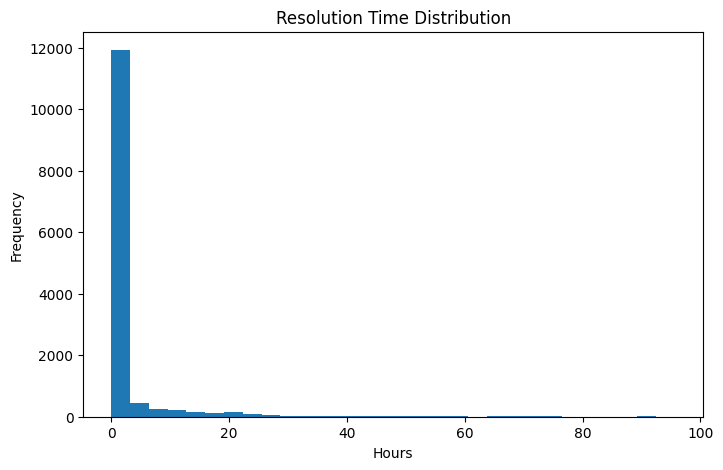

In [78]:
plt.figure(figsize=(8,5))

plt.hist(df['Resolution_Time_Hours'], bins=30)

plt.title('Resolution Time Distribution')
plt.xlabel('Hours')
plt.ylabel('Frequency')

plt.show()

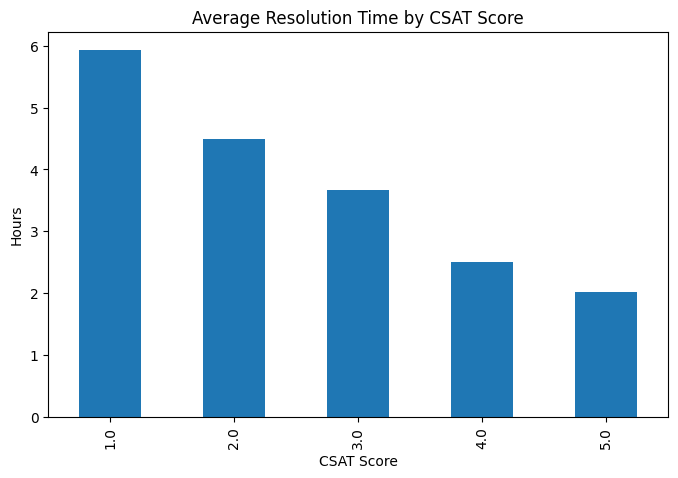

In [79]:
avg_time = df.groupby('CSAT Score')['Resolution_Time_Hours'].mean()

plt.figure(figsize=(8,5))

avg_time.plot(kind='bar')

plt.title('Average Resolution Time by CSAT Score')
plt.ylabel('Hours')

plt.show()

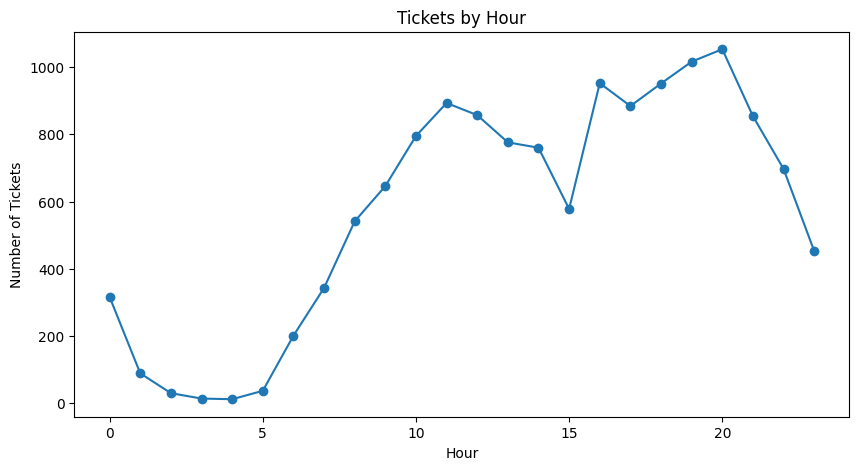

In [80]:
hourly = df['Report_Hour'].value_counts().sort_index()

plt.figure(figsize=(10,5))

hourly.plot(kind='line', marker='o')

plt.title('Tickets by Hour')
plt.xlabel('Hour')
plt.ylabel('Number of Tickets')

plt.show()

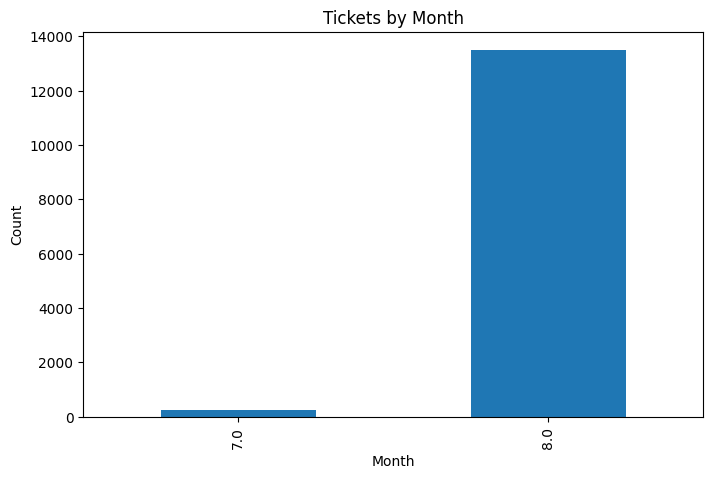

In [81]:
monthly = df['Report_Month'].value_counts().sort_index()

plt.figure(figsize=(8,5))

monthly.plot(kind='bar')

plt.title('Tickets by Month')
plt.xlabel('Month')
plt.ylabel('Count')

plt.show()

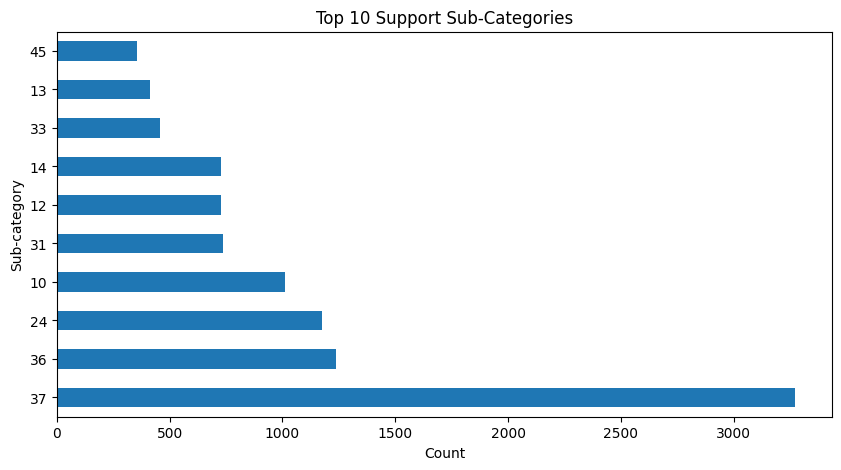

In [82]:
top_sub = df['Sub-category'].value_counts().head(10)

plt.figure(figsize=(10,5))

top_sub.plot(kind='barh')

plt.title('Top 10 Support Sub-Categories')
plt.xlabel('Count')

plt.show()